# 프로젝트: 한국어 데이터로 챗봇 만들기

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1. 데이터 수집하기
---
한국어 챗봇 데이터는 송영숙님이 공개한 챗봇 데이터를 사용합니다.

이 데이터는 아래의 링크에서 다운로드할 수 있습니다.

- [songys/Chatbot_data](https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv)

Local terminal에서 아래 명령어를 입력해 주세요.


```
$ mkdir -p /content/aiffel/transformer_chatbot/data/ && cd /content/aiffel/transformer_chatbot/data/
$ wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData%20.csv
```

In [2]:
data = pd.read_csv('data/ChatbotData.csv')
print(data.sample(10))

                                  Q                           A  label
6811                          씁쓸하네.                    제가 있잖아요.      1
186                 고무신 거꾸로 신으면 어쩌지                너무 걱정하지 마세요.      0
9036  구여친이랑 헤어진지 꽤 됐는데 좋아하는 사람이 없음.         조급하게 생각하지 않아도 된답니다.      2
7509                 이별은 다 비슷한거 같아.              이별은 똑같이 힘드니까요.      1
9085                 그는 지금 뭐하고 있을까.           궁금하면 용기내서 연락해보세요.      2
8539                      헤어지고 힘들다.                    헤어졌으니까요.      1
669                     나한테만 예의 차리래  오는 말이 고와야 가는 말도 곱다고 말해주세요.      0
9294                   남자친구 코 완전 높아          멋진 사람이랑 사귀어서 좋겠네요.      2
6001           눈물이 말랐는지 슬퍼도 감정이안나오네                     참지 마세요.      1
5502                  결국 이렇게 될 꺼면서.         시작할 때는 그 끝을 알지 못하죠.      1


In [3]:
print('data 총 개수: ', len(data))
print(data.isnull().sum())   # 결측치 확인

data 총 개수:  11823
Q        0
A        0
label    0
dtype: int64


In [4]:
# 질문(Q)과 답변(A)을 각각의 리스트로 분리
questions = data['Q'].tolist()
answers = data['A'].tolist()

print('questions 개수: ', len(questions))
print('answers 개수: ', len(answers))
print('questions[:3]: ', questions[:3])
print('answers[:3]: ', answers[:3])

questions 개수:  11823
answers 개수:  11823
questions[:3]:  ['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
answers[:3]:  ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## Step 2. 데이터 전처리하기
---
영어 데이터와는 전혀 다른 데이터인 만큼 영어 데이터에 사용했던 전처리와 일부 동일한 전처리도 필요하겠지만 전체적으로는 다른 전처리를 수행해야 할 수도 있습니다.

In [5]:
# 전처리 함수
def preprocess_sentence(sentence):
    # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
    sentence = sentence.lower().strip()

    # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
    # student와 온점 사이에 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # (가-힣, ㄱ-ㅎ, ㅏ-ㅣ, a-z, A-Z, 0-9, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)   # 연속 공백 정리
    sentence = sentence.strip()
    return sentence

"ㅋㅋ", "ㅠㅠ" 등을 감정 신호로 보아 남겨두기로 결정

In [6]:
sample_sentence = questions[0]

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

12시 땡 !


In [7]:
# 전처리 적용 후 (질문, 답변) 병렬 데이터를 만듦
pairs = []
for q, a in zip(questions, answers):
    q = preprocess_sentence(q)
    a = preprocess_sentence(a)

    # 빈 문장이 된 쌍은 제외
    if len(q) == 0 or len(a) == 0:
        continue

    pairs.append((q, a))

print('전처리 후 쌍 개수: ', len(pairs), f'({len(questions) - len(pairs)}개 제외)')

# 질문과 답변이 모두 같은 완전 중복 쌍 제거
seen = set()
unique_pairs = []
for pair in pairs:
    if pair in seen:
        continue
    seen.add(pair)
    unique_pairs.append(pair)

print('중복 제거 후 쌍 개수: ', len(unique_pairs), f'(중복 {len(pairs) - len(unique_pairs)}개 제거)')
pairs = unique_pairs

# 만들어진 병렬 데이터 확인
for q, a in pairs[:5]:
    print('Q: ', q)
    print('A: ', a)
    print()

전처리 후 쌍 개수:  11823 (0개 제외)
중복 제거 후 쌍 개수:  11749 (중복 74개 제거)
Q:  12시 땡 !
A:  하루가 또 가네요 .

Q:  1지망 학교 떨어졌어
A:  위로해 드립니다 .

Q:  3박4일 놀러가고 싶다
A:  여행은 언제나 좋죠 .

Q:  3박4일 정도 놀러가고 싶다
A:  여행은 언제나 좋죠 .

Q:  ppl 심하네
A:  눈살이 찌푸려지죠 .



## Step 3. SentencePiece 사용하기
---
한국어 데이터는 형태소 분석기를 사용하여 토크나이징을 해야 한다고 많은 분이 알고 있습니다. 하지만 여기서는 형태소 분석기가 아닌 위 실습에서 사용했던 서브워드 토크나이저인 SentencePiece를 그대로 사용해보세요.

In [8]:
sents = [s for pair in pairs for s in pair]

# pairs를 txt 파일로 저장
corpus_file = "clean_corpus_ko.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [9]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_ko",
    vocab_size=4000,
    character_coverage=0.9995,   # 한국어 권장
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

True

In [10]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_ko.model")

print('vocab size:', sp.get_piece_size())   # vocab 크기

all_ids = [i for s in sents for i in sp.encode(s)]   # UNK 비율
print('UNK 비율: {:.4f}%'.format(
    sum(1 for i in all_ids if i == sp.unk_id()) / len(all_ids) * 100))

print('문장당 평균 토큰 수: {:.2f}'.format(len(all_ids) / len(sents)))

# 예제 확인
sentence = "3박4일 놀러가고 싶다"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1) 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2) 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3) 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

vocab size: 4000
UNK 비율: 0.1157%
문장당 평균 토큰 수: 6.51
전처리 후의 문장: 3박4일 놀러가고 싶다
Tokenized: ['▁3', '박', '4', '일', '▁놀러', '가고', '▁싶다']
Encoded: [479, 3437, 3405, 2979, 1116, 969, 202]
Decoded: 3박4일 놀러가고 싶다


In [11]:
from collections import Counter

cnt = Counter(all_ids)
size = sp.get_piece_size()
print('실제 등장한 조각: {} / {} ({:.1f}%)'.format(len(cnt), size, len(cnt) / size * 100))
print('5회 미만 등장: {} ({:.1f}%)'.format(
    sum(1 for v in cnt.values() if v < 5),
    sum(1 for v in cnt.values() if v < 5) / size * 100))

실제 등장한 조각: 3887 / 4000 (97.2%)
5회 미만 등장: 374 (9.3%)


### MAX_LEN 설정

질문의 최소 길이 : 1
질문의 최대 길이 : 25
질문의 평균 길이 : 6.26
답변의 최소 길이 : 1
답변의 최대 길이 : 32
답변의 평균 길이 : 6.76


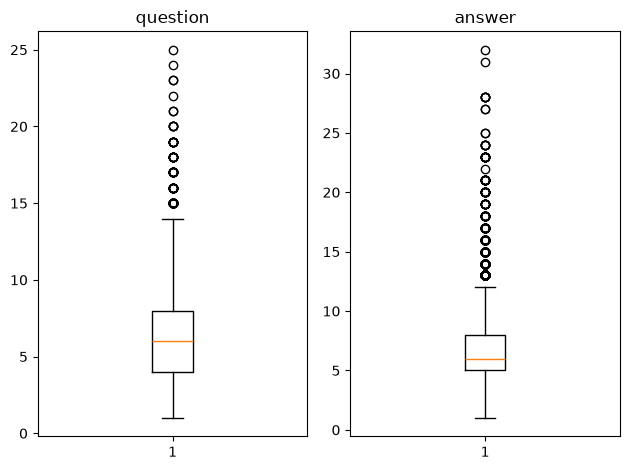

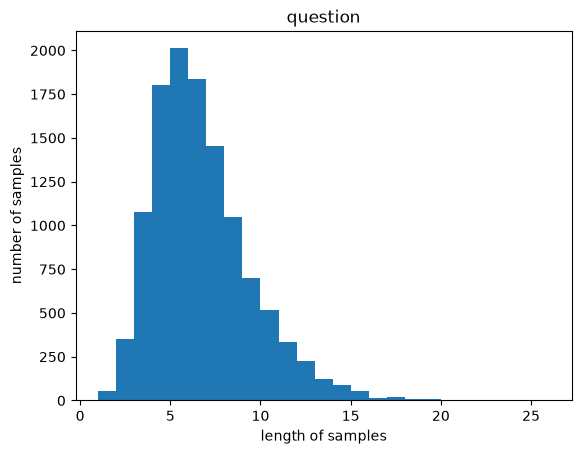

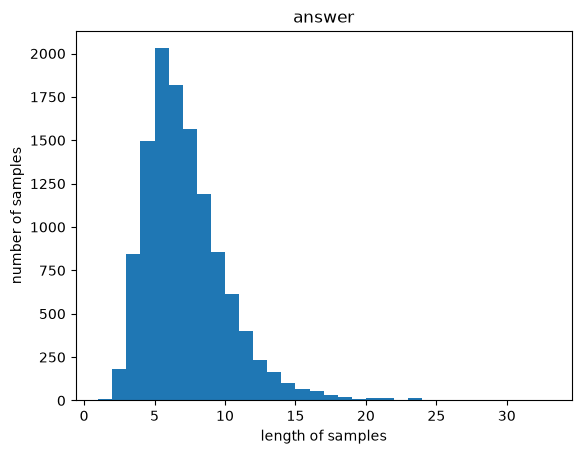

In [12]:
# 토큰 길이 분포 출력
import matplotlib.pyplot as plt

q_tokens = [len(sp.encode(q)) for q, a in pairs]
a_tokens = [len(sp.encode(a)) for q, a in pairs]

print('질문의 최소 길이 : {}'.format(np.min(q_tokens)))
print('질문의 최대 길이 : {}'.format(np.max(q_tokens)))
print('질문의 평균 길이 : {:.2f}'.format(np.mean(q_tokens)))
print('답변의 최소 길이 : {}'.format(np.min(a_tokens)))
print('답변의 최대 길이 : {}'.format(np.max(a_tokens)))
print('답변의 평균 길이 : {:.2f}'.format(np.mean(a_tokens)))

plt.subplot(1,2,1)
plt.boxplot(q_tokens)
plt.title('question')
plt.subplot(1,2,2)
plt.boxplot(a_tokens)
plt.title('answer')
plt.tight_layout()
plt.show()

plt.title('question')
plt.hist(q_tokens, bins=range(1, np.max(q_tokens) + 2))
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('answer')
plt.hist(a_tokens, bins=range(1, np.max(a_tokens) + 2))
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [13]:
def below_threshold_len(max_length, q_tokens, a_tokens):
    """MAX_LENGTH 안에 들어오는 (질문, 답변) 쌍의 비율 출력 (+2 = <bos>, <eos>)"""
    cnt = 0
    for qt, at in zip(q_tokens, a_tokens):
        if qt + 2 <= max_length and at + 2 <= max_length:
            cnt = cnt + 1
    print('MAX_LENGTH=%s 이하인 쌍의 비율: %.4f  (유지 %s / %s, 손실 %s쌍)'
          % (max_length, cnt / len(q_tokens), cnt, len(q_tokens), len(q_tokens) - cnt))

In [14]:
max_len = 22
below_threshold_len(max_len, q_tokens, a_tokens)

MAX_LENGTH=22 이하인 쌍의 비율: 0.9956  (유지 11697 / 11749, 손실 52쌍)


### Dataset 구축하기

In [15]:
class KoreanDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            a_tokens += [0]*(max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [16]:
dataset = KoreanDataset(pairs, sp, max_length=22)
print(len(dataset))

11697


## Step 4. 모델 구성하기
---

### Transformer 구조 및 shape 변화

NUM_LAYERS=2, D_MODEL=256, NUM_HEADS=8 (depth 32), UNITS=512, VOCAB_SIZE=4000, DROPOUT=0.3

batch=32, 인코더 길이=22, 디코더 길이=21

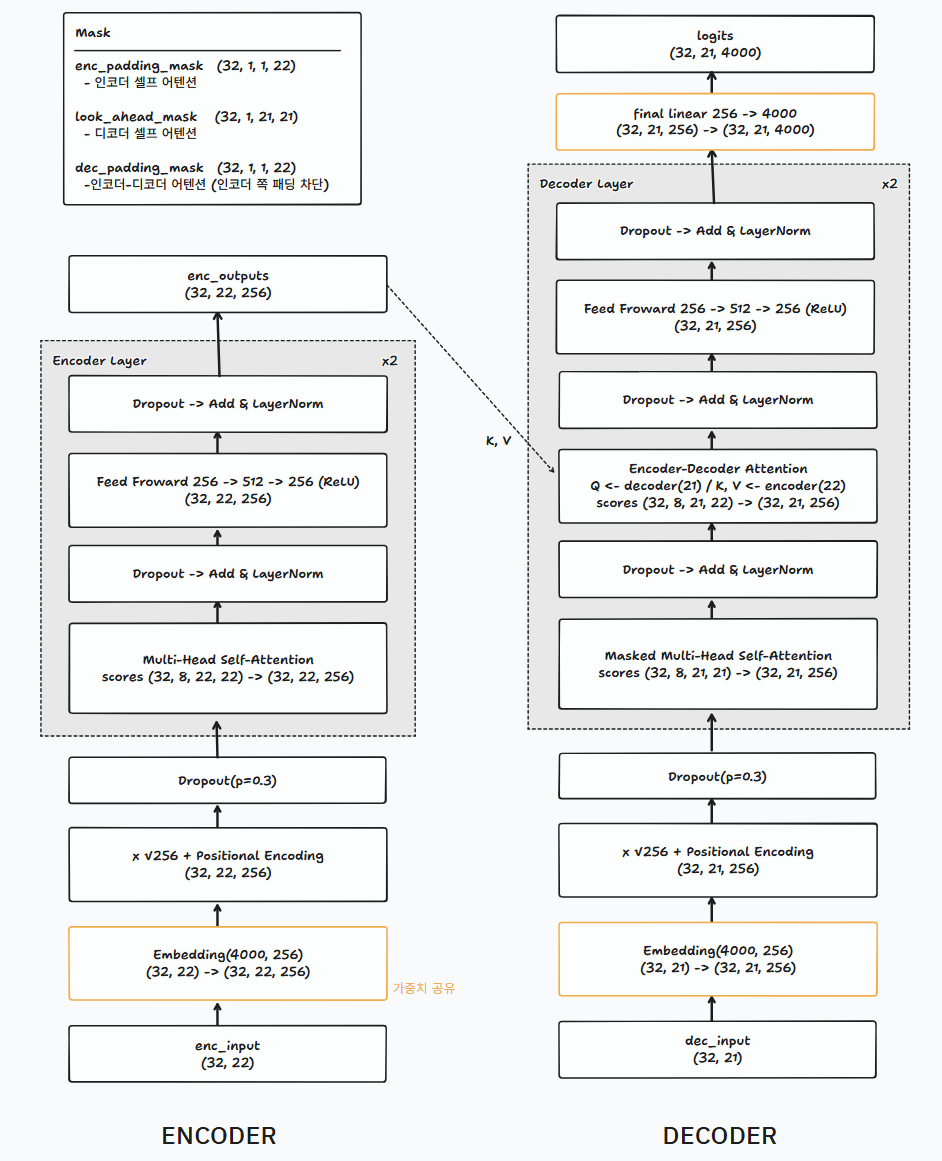

### DataLoader 구성하기

In [17]:
from torch.utils.data import random_split

# Early Stopping 판단을 위해 학습/검증 데이터로 분할
VAL_RATIO = 0.05   # 훈련 95% | 검증 5%
BATCH_SIZE = 32

val_size = int(len(dataset) * VAL_RATIO)
train_size = len(dataset) - val_size

# 재현성을 위해 seed 고정
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
print('train: {} / validation: {}'.format(len(train_dataset), len(val_dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print('steps per epoch:', len(train_loader))

for encoder_input, decoder_input, decoder_label in train_loader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

train: 11113 / validation: 584
steps per epoch: 348
torch.Size([32, 22])
torch.Size([32, 21])
torch.Size([32, 21])


### 모델

#### Positional Encoding: 위치 정보 추가

In [77]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model     # 임베딩 벡터의 차원
        self.position = position   # 입력 문장에서의 임베딩 벡터의 위치

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

#### Scaled Dot-Product Attention: 스케일링한 어텐션

In [19]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

#### Multi-Head Attention: 병렬 연산 어텐션

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        # matmul이 뒤쪽 2개 축만 보기 때문에 seq_len, depth가 뒤에 오도록 변경해야 함
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        # 반환값: (batch_size, 1, seq_len, seq_len), 두 번째 반환값: 어텐션 가중치
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


#### Multi-Head Attention shape 흐름

d_model=256, num_heads=8, depth=32, batch=32, seq_len=10 기준

| 단계 | shape |
|---|---|
| 입력 query/key/value | (32, 10, 256)|
| Linear 통과 후	| (32, 10, 256) |
| view (헤드 분할) | (32, 10, 8, 32) |
| permute | (32, 8, 10, 32) |
| 어텐션 스코어 (내부) | (32, 8, 10, 10) |
| 어텐션 출력 | (32, 8, 10, 32) |
| permute 복원 | (32, 10, 8, 32) |
| view (concat) | (32, 10, 256) |
| out_dense | (32, 10, 256) |

#### Mask
- Padding Mask: 인코더에서 사용하며 pad 처리된 위치 가림
- Look ahead Mask: 디코더에서 사용하며 미래 정보 차단

In [21]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [22]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

#### Encoder

In [23]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2

In [24]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

#### Decoder

In [25]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [26]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

#### Transformer

In [27]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [43]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2                    # 인코더/디코더 층 수
D_MODEL = 256                     # 임베딩 및 내부 표현 차원
NUM_HEADS = 8                     # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512                       # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3                     # 드롭아웃 비율
VOCAB_SIZE = sp.get_piece_size()  # 단어 집합 크기 (토크나이저와 항상 일치)
MAX_LENGTH = 22                   # 학습에 사용할 최대 길이

print('VOCAB_SIZE:', VOCAB_SIZE)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print('가중치 공유 전 파라미터: {:,}'.format(sum(p.numel() for p in model.parameters())))

# 베딩 가중치 공유 (인코더 임베딩 = 디코더 임베딩 = 출력층)
# 질문과 답변이 같은 SentencePiece 어휘를 쓰므로 4000x256 표를 3개 둘 이유가 없다.
model.decoder.embedding.weight = model.encoder.embedding.weight
model.final_linear.weight = model.encoder.embedding.weight

nn.init.normal_(model.encoder.embedding.weight, mean=0.0, std=D_MODEL ** -0.5)
nn.init.zeros_(model.final_linear.bias)
print('가중치 공유 후 파라미터: {:,}'.format(sum(p.numel() for p in model.parameters())))

print(model)

VOCAB_SIZE: 4000
가중치 공유 전 파라미터: 5,711,776
가중치 공유 후 파라미터: 3,663,776
Transformer(
  (encoder): Encoder(
    (embedding): Embedding(4000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.3, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.3, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.3, inplace=F

### Learning Rate 설정

In [44]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

steps/epoch: 348 / 총 학습 스텝: 34800
warmup 종료 시점: 2.9 epoch


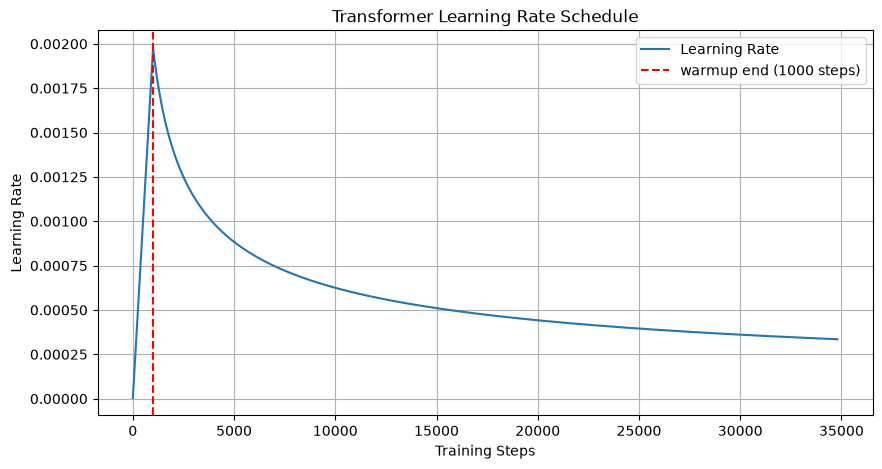

In [45]:
# 학습 설정
warmup_steps = 1000   # 전체 학습 스텝에 맞춰 조정
NUM_EPOCHS = 100      # Early Stopping이 있으므로 넉넉히 설정
PATIENCE = 10         # val_acc 기준

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * NUM_EPOCHS
print('steps/epoch: {} / 총 학습 스텝: {}'.format(steps_per_epoch, total_steps))
print('warmup 종료 시점: {:.1f} epoch'.format(warmup_steps / steps_per_epoch))

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(D_MODEL, warmup_steps)(step) for step in steps]

plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.axvline(warmup_steps, color='r', linestyle='--',
            label="warmup end ({} steps)".format(warmup_steps))
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

### Optimizer & Scheduler & Loss Function

In [46]:
# Optimizer 정의
# LambdaLR은 base_lr × lambda 로 곱하므로, get_lr_lambda 공식값을 그대로
# 실제 학습률로 쓰려면 base_lr=1.0 으로 두어야 합니다. (기본값 0.001이면 1/1000 스케일)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=warmup_steps))

# Loss Function - label smoothing 적용
# 챗봇은 정답이 여럿인 one-to-many 문제이므로 이 완화가 유효하다.
LABEL_SMOOTHING = 0.1
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=LABEL_SMOOTHING)

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)      # 정답이 패딩이 아닌 위치만 True
    correct = (preds == y_true) & mask   # 맞혔고, 채점 대상(mask)인 위치만 True
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)
device

device(type='cuda')

### 훈련하기

In [48]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    acc = accuracy_function(logits, target, pad_id=sp.pad_id())
    return loss.item(), acc.item()


def evaluate(model, dataloader, loss_function, device):
    """검증 데이터에 대한 loss/accuracy 계산 (Early Stopping 판단용)"""
    model.eval()
    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for batch in dataloader:
            enc_input, dec_input, target = [x.to(device) for x in batch]

            logits = model(enc_input, dec_input)
            loss = loss_function(logits.permute(0, 2, 1), target)
            acc = accuracy_function(logits, target, pad_id=sp.pad_id())

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(dataloader), total_acc / len(dataloader)

In [49]:
def train(model, train_loader, val_loader, optimizer, loss_function, scheduler,
          num_epochs, device, patience=10, checkpoint_path='best_model.pt'):

    model.to(device)
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0

        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                cur_lr = optimizer.param_groups[0]['lr']
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}, lr: {cur_lr:.6f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = total_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} Completed - loss: {avg_loss:.4f}, acc: {avg_acc:.4f} | "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

        # best 갱신 여부 확인 (기준: val_acc 최대값)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, checkpoint_path)
            print(f"  >> best 갱신 (val_acc {best_val_acc:.4f}) - '{checkpoint_path}'에 저장")
        else:
            patience_counter += 1
            print(f"  >> 개선 없음 ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"\nEarly Stopping: {patience}에폭 동안 val_acc가 개선되지 않아 중단")
                break

    # 학습 종료 후 best 에폭의 가중치를 복원
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n최종: epoch {best_epoch}의 가중치 복원 완료 "
          f"(val_acc {best_val_acc:.4f}, val_loss {checkpoint['val_loss']:.4f})")

    history['best_epoch'] = best_epoch
    history['best_val_acc'] = best_val_acc
    return history

In [50]:
%%time

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=PATIENCE,
    checkpoint_path='best_model_exp2.pt'
)

[Epoch 1, Step 0] Loss: 9.9196, Acc: 0.0000, lr: 0.000002
[Epoch 1, Step 100] Loss: 6.6641, Acc: 0.2460, lr: 0.000200
[Epoch 1, Step 200] Loss: 6.1662, Acc: 0.2605, lr: 0.000397
[Epoch 1, Step 300] Loss: 5.6009, Acc: 0.3267, lr: 0.000595
Epoch 1 Completed - loss: 6.5367, acc: 0.2178 | val_loss: 5.8362, val_acc: 0.2675
  >> best 갱신 (val_acc 0.2675) - 'best_model_exp2.pt'에 저장
[Epoch 2, Step 0] Loss: 5.7724, Acc: 0.2680, lr: 0.000690
[Epoch 2, Step 100] Loss: 5.6792, Acc: 0.2876, lr: 0.000887
[Epoch 2, Step 200] Loss: 5.5660, Acc: 0.2800, lr: 0.001085
[Epoch 2, Step 300] Loss: 5.0722, Acc: 0.3348, lr: 0.001283
Epoch 2 Completed - loss: 5.5866, acc: 0.2882 | val_loss: 5.3184, val_acc: 0.3019
  >> best 갱신 (val_acc 0.3019) - 'best_model_exp2.pt'에 저장
[Epoch 3, Step 0] Loss: 5.0513, Acc: 0.3235, lr: 0.001378
[Epoch 3, Step 100] Loss: 5.2171, Acc: 0.3030, lr: 0.001575
[Epoch 3, Step 200] Loss: 4.9352, Acc: 0.3230, lr: 0.001773
[Epoch 3, Step 300] Loss: 5.3488, Acc: 0.2952, lr: 0.001970
Epoch 3 

### 학습 곡선 확인

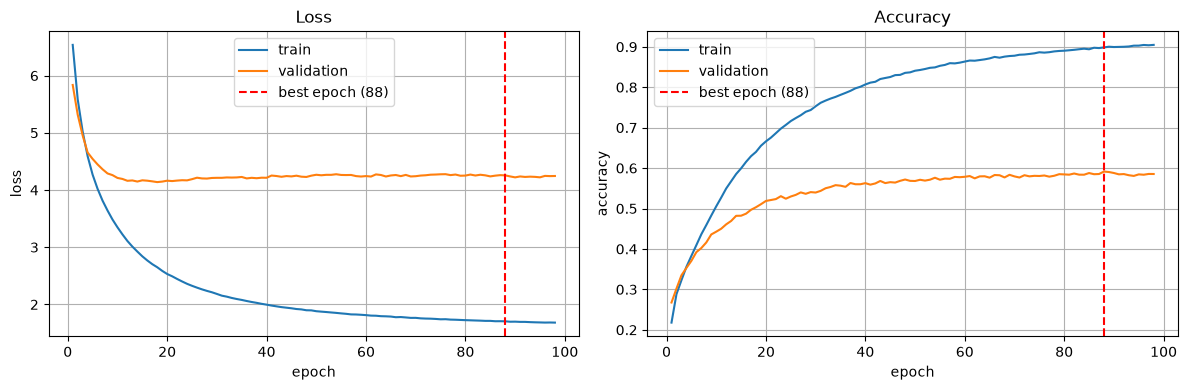

총 학습 에폭: 98
best epoch: 88 (val_acc 0.5914)


In [51]:
epochs = range(1, len(history['loss']) + 1)
best_epoch = history['best_epoch']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['loss'], label='train')
plt.plot(epochs, history['val_loss'], label='validation')
plt.axvline(best_epoch, color='r', linestyle='--', label='best epoch ({})'.format(best_epoch))
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['acc'], label='train')
plt.plot(epochs, history['val_acc'], label='validation')
plt.axvline(best_epoch, color='r', linestyle='--', label='best epoch ({})'.format(best_epoch))
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('총 학습 에폭: {}'.format(len(history['loss'])))
print('best epoch: {} (val_acc {:.4f})'.format(best_epoch, history['best_val_acc']))

## Step 5. 모델 평가하기
---
Step 1에서 선택한 전처리 방법을 고려하여 입력된 문장에 대해서 대답을 얻는 예측 함수를 만듭니다.

In [70]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 22


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 학습 때와 동일하게 bos/eos 포함 max_length 이내로 절단
    enc_input_ids = tokenizer.encode(sentence)[: MAX_LENGTH - 2]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([[START_TOKEN] + enc_input_ids + [END_TOKEN]], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for _ in range(MAX_LENGTH - 1):   # dec_input이 max_length를 넘지 않도록
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [71]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [72]:
sentence = '잘 지냈어?'
sentence_generation(model, sentence, sp, device)

입력 : 잘 지냈어?
출력 : 안부를 물어주시다니 감사합니다 .


'안부를 물어주시다니 감사합니다 .'

In [73]:
sentence = '배고프다.'
sentence_generation(model, sentence, sp, device)

입력 : 배고프다.
출력 : 얼른 맛난 음식 드세요 .


'얼른 맛난 음식 드세요 .'

In [74]:
sentence = '해외로 놀러가고 싶다~!'
sentence_generation(model, sentence, sp, device)

입력 : 해외로 놀러가고 싶다~!
출력 : 칭찬 감사합니다 .


'칭찬 감사합니다 .'

In [75]:
sentence = '감기에 걸렸어.'
sentence_generation(model, sentence, sp, device)

입력 : 감기에 걸렸어.
출력 : 이럴 때 잘 쉬는 게 중요해요 .


'이럴 때 잘 쉬는 게 중요해요 .'

In [76]:
sentence = '요즘 힘들어'
sentence_generation(model, sentence, sp, device)

입력 : 요즘 힘들어
출력 : 지금은 힘들겠지만 조금만 더 견뎌봐요 .


'지금은 힘들겠지만 조금만 더 견뎌봐요 .'

---

## 실험

### [실험 1] vocab size 설정하기

#### 1. vocab size = 8000

- vocab size: 8000
- UNK 비율: 0.1349%
- 문장당 평균 토큰 수: 5.58
- 실제 등장한 조각: 7543 / 8000 (94.3%)
- 5회 미만 등장: 2342 (29.3%)

```
전처리 후의 문장: 3박4일 놀러가고 싶다
Tokenized: ['▁3', '박', '4', '일', '▁놀러가고', '▁싶다']
Encoded: [479, 7437, 7405, 6979, 3466, 202]
Decoded: 3박4일 놀러가고 싶다
```


#### 2. vocab size = 4000

- vocab size: 4000
- UNK 비율: 0.1157%
- 문장당 평균 토큰 수: 6.51
- 실제 등장한 조각: 3887 / 4000 (97.2%)
- 5회 미만 등장: 374 (9.3%)

```
전처리 후의 문장: 3박4일 놀러가고 싶다
Tokenized: ['▁3', '박', '4', '일', '▁놀러', '가고', '▁싶다']
Encoded: [479, 3437, 3405, 2979, 1116, 969, 202]
Decoded: 3박4일 놀러가고 싶다
```

#### 결론
SentencePiece에서 vocab_size를 4000과 8000으로 각각 학습해 비교했다. UNK 절대 개수는 177개로 동일해 판단 근거가 되지 못했다. 5회 미만 등장한 어휘가 8000은 29.3%인 반면 4000은 9.3%이다. 토큰화 결과에서도 8000은 `놀러가고`를 한 덩어리로 병합해 재사용성이 떨어졌다. 학습 데이터가 11,749쌍으로 작은 점을 고려해 vocab_size = 4000을 선택했다.

---

### [실험 2] Accuracy 높이기

### 1. 기존

#### 1) 설정

| 구분 | 항목 | 값 |
|---|---|---|
| 데이터 | 학습 / 검증 | 11,113쌍 / 584쌍 (5% 분할, seed 42) |
| | MAX_LENGTH | 22 |
| | VOCAB_SIZE | 4000 (SentencePiece) |
| 모델 | NUM_LAYERS | 2 |
| | D_MODEL / NUM_HEADS | 256 / 8 (depth 32) |
| | UNITS (FFN) | 512 |
| | DROPOUT | 0.3 |
| | 총 파라미터 | 5,711,776 |
| 학습 | BATCH_SIZE | 32 (348 steps/epoch) |
| | Optimizer | Adam(lr=1.0, betas=(0.9, 0.98), eps=1e-9) |
| | Scheduler | LambdaLR (Noam), warmup_steps=1000 (2.9 epoch) |
| | Loss | CrossEntropyLoss(ignore_index=pad) |
| | NUM_EPOCHS / PATIENCE | 50 / 5 (판정 기준: val_loss) |

#### 2) 결과

27에폭에서 Early Stopping이 작동했고, best epoch 22의 가중치를 복원했다.

| epoch | loss | acc | val_loss | val_acc |
|---|---|---|---|---|
| 1 | 6.0514 | 0.2400 | 5.2786 | 0.2728 |
| 5 | 3.5030 | 0.3864 | 3.9097 | 0.3795 |
| 10 | 2.6861 | 0.4840 | 3.5409 | 0.4408 |
| 16 | 2.2611 | 0.5521 | 3.4322 | 0.4993 |
| 19 | 2.1315 | 0.5754 | 3.3999 | 0.5174 |
| **22 (best)** | **2.0293** | **0.5950** | **3.3949** | **0.5325** |
| 25 | 1.9501 | 0.6111 | 3.4077 | 0.5401 |
| 27 (중단) | 1.8990 | 0.6204 | 3.4131 | **0.5471** |

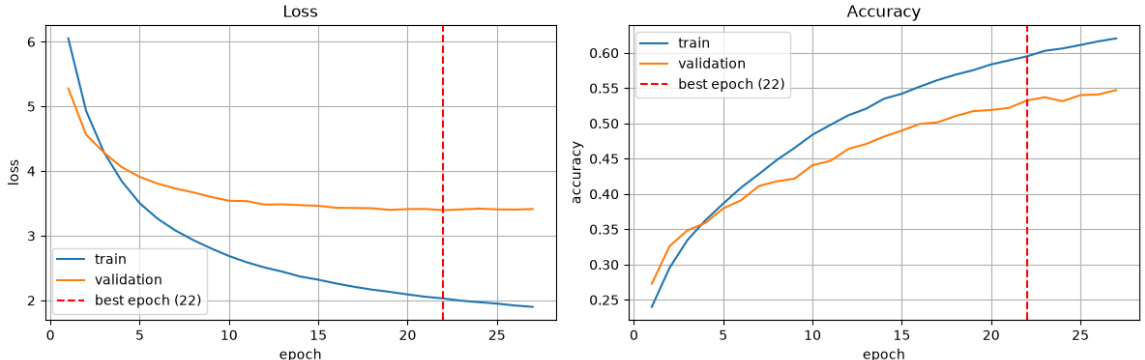

생성 결과:

```
입력 : 잘 지냈어?     출력 : 같이해보세요 .
입력 : 배고프다.      출력 : 좋은 사람 만날 거예요 .
```

#### 3) 문제

**(1) Early Stopping 기준과 실제 개선 방향의 불일치**

`val_loss`는 16에폭 이후 3.39~3.43 구간에서 평탄해졌고, best로 기록된 22에폭도 0.01 수준의 차이에 불과했다. 반면 `val_acc`는 중단 시점까지 한 번도 꺾이지 않고 증가했다(0.4993 → 0.5471).

그 결과 두 가지 손해가 발생했다.

- 평탄한 노이즈 구간을 "개선 없음"으로 판정해, 아직 개선 중인 학습을 27에폭에서 중단
- 종료 후 best(22에폭) 가중치를 복원하면서 val_acc가 0.5471 → 0.5325로 후퇴

CrossEntropy는 예측의 확신도까지 벌점을 매기므로 과적합 구간에서 상승하지만, argmax 정확도는 그와 무관하게 계속 개선될 수 있다. 생성 품질에 직결되는 것은 `val_acc`이다.

**(2) 과적합**

학습 손실 1.90 대 검증 손실 3.41로 격차가 1.5에 달한다. 파라미터 571만 개에 비해 학습 데이터가 11,113쌍으로 작고, 특히 파라미터 구성이 불균형하다.

| 구성 | 파라미터 | 비중 |
|---|---|---|
| 임베딩 (인코더 + 디코더) | 2,048,000 | 36% |
| 출력층 (final_linear) | 1,028,000 | 18% |
| 인코더 2층 | 1,054,208 | 18% |
| 디코더 2층 | 1,581,568 | 28% |

전체의 54%가 임베딩과 출력층에 몰려 있다. 학습쌍 하나당 파라미터가 514개인 셈이다.

**(3) 생성 품질: 질문과 답변의 연결이 약함**

두 출력 모두 문법적으로 완결된 한국어이고 챗봇 특유의 존댓말 어투를 갖췄으므로 언어 모델링 자체는 학습되었다. 그러나 질문 내용과 답변이 연결되지 않는다.

| 입력 | 데이터의 실제 답변 | 모델 출력 |
|---|---|---|
| 잘 지냈어? (데이터에 동일 문장 존재) | 안부를 물어주시다니 감사합니다. | 같이해보세요. |
| 배고프다. (유사 질문 14건 존재) | 얼른 맛난 음식 드세요. | 좋은 사람 만날 거예요. |

과적합된 모델에 greedy 디코딩을 적용할 때 나타나는 전형적인 증상으로, 질문과 무관하게 빈출 답변 패턴을 출력한다.


#### 4) 해결 방안

1. Early Stopping 판정 기준을 `val_acc` 최대값으로 변경 -> 추가 학습 여지 확보
2. 임베딩 가중치 공유 (인코더 = 디코더 = 출력층) -> 파라미터 감소 및 과적합 완화
3. CrossEntropyLoss에 label_smoothing 추가 ->과적합 완화 및 일반화 성능 향상

### 2. 개선 적용

#### 1) 설정

`1. 기존`의 해결 방안 3가지를 모두 적용했다. 변경한 항목은 굵게 표시했다.

| 구분 | 항목 | 값 |
|---|---|---|
| 데이터 | 학습 / 검증 | 11,113쌍 / 584쌍 (5% 분할, seed 42) |
| | MAX_LENGTH | 22 |
| | VOCAB_SIZE | 4000 (SentencePiece) |
| 모델 | NUM_LAYERS | 2 |
| | D_MODEL / NUM_HEADS | 256 / 8 (depth 32) |
| | UNITS (FFN) | 512 |
| | DROPOUT | 0.3 |
| | **임베딩 가중치 공유** | **인코더 = 디코더 = 출력층** |
| | **임베딩 초기화** | **std = d_model^-0.5 = 0.0625** |
| | **총 파라미터** | **3,663,776** (5,711,776 대비 -36%) |
| 학습 | BATCH_SIZE | 32 (348 steps/epoch) |
| | Optimizer | Adam(lr=1.0, betas=(0.9, 0.98), eps=1e-9) |
| | Scheduler | LambdaLR (Noam), warmup_steps=1000 (2.9 epoch) |
| | **Loss** | **CrossEntropyLoss(ignore_index=pad, label_smoothing=0.1)** |
| | **NUM_EPOCHS / PATIENCE** | **100 / 10 (판정 기준: val_acc)** |

**주의 1. 가중치 공유에는 임베딩 초기화가 함께 필요하다.**

`nn.Embedding`의 기본 초기화는 std=1.0인 반면 `nn.Linear`는 std≈0.036이다. 초기화를 그대로 둔 채 출력층에 임베딩을 묶으면 출력층 가중치가 약 28배 커져 로짓이 폭발한다. 실제로 초기화 없이 실행했을 때 첫 스텝 loss가 171.68을 기록했고(정상값 ln(4000)≈8.3), 폭발에서 회복하는 데 3에폭을 소모한 뒤 50에폭을 학습하고도 val_acc가 0.4325에 그쳤다.

`std = d_model^-0.5 = 0.0625`로 초기화하면 하나의 행렬이 두 역할을 동시에 만족한다.

| 역할 | 요구 스케일 | 결과 |
|---|---|---|
| 입력 임베딩 | 1.0 (Positional Encoding, LayerNorm과 균형) | 0.0625 × √256 = **1.0** |
| 출력층 | 0.0625 (= 1/√fan_in, 로짓 스케일 1) | **0.0625** |

두 요구가 정확히 √d_model = 16배 어긋나므로, `embedding(x) * sqrt(d_model)`이 그 간극을 메운다.

```python
model.decoder.embedding.weight = model.encoder.embedding.weight
model.final_linear.weight = model.encoder.embedding.weight
nn.init.normal_(model.encoder.embedding.weight, mean=0.0, std=D_MODEL ** -0.5)
```


**주의 2. label smoothing 적용 후에는 loss 절대값을 비교할 수 없다.**

목표 분포 자체에 불확실성이 섞이므로 완벽한 모델이라도 loss가 0이 되지 않는다. vocab 4000, smoothing 0.1에서 하한은 약 1.15이다. 따라서 실험 간 비교는 `val_acc`로만 수행한다.

#### 2) 결과

98에폭에서 Early Stopping이 작동했고, best epoch 88의 가중치를 복원했다. 학습 시간 23분 55초.

| epoch | loss | acc | val_loss | val_acc |
|---|---|---|---|---|
| 1 | 6.5367 | 0.2178 | 5.8362 | 0.2675 |
| 5 | 4.2687 | 0.3829 | 4.5437 | 0.3706 |
| 10 | 3.3485 | 0.5054 | 4.2112 | 0.4427 |
| 20 | 2.5319 | 0.6661 | 4.1629 | 0.5188 |
| 30 | 2.1834 | 0.7529 | 4.2129 | 0.5396 |
| 40 | 1.9959 | 0.8068 | 4.2138 | 0.5628 |
| 50 | 1.8813 | 0.8408 | 4.2665 | 0.5681 |
| 60 | 1.8129 | 0.8635 | 4.2434 | 0.5785 |
| 70 | 1.7653 | 0.8779 | 4.2413 | 0.5794 |
| 80 | 1.7250 | 0.8903 | 4.2522 | 0.5844 |
| **88 (best)** | **1.7051** | **0.8985** | 4.2562 | **0.5914** |
| 98 (중단) | 1.6821 | 0.9047 | 4.2449 | 0.5854 |

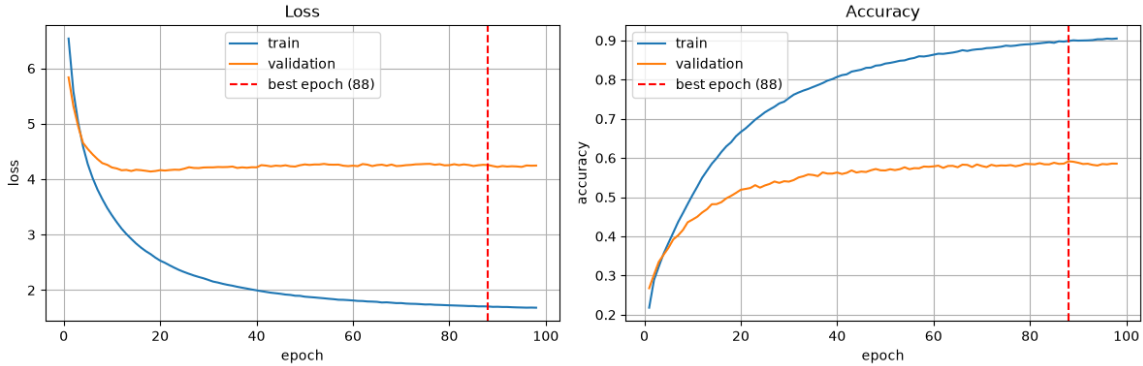

생성 결과:

```
입력 : 잘 지냈어?            출력 : 안부를 물어주시다니 감사합니다 .
입력 : 배고프다.             출력 : 얼른 맛난 음식 드세요 .
입력 : 해외로 놀러가고 싶다~!  출력 : 칭찬 감사합니다 .
입력 : 감기에 걸렸어.         출력 : 이럴 때 잘 쉬는 게 중요해요 .
```

**실험 1과의 비교**

| 항목 | 1. 기존 | 2. 개선 적용 |
|---|---|---|
| 총 파라미터 | 5,711,776 | **3,663,776** |
| 학습 에폭 | 27 (Early Stopping 작동) | 98 (Early Stopping 작동) |
| best epoch | 22 | 88 |
| **최종 val_acc** | 0.5325 | **0.5914** |
| 학습 시간 | 6분 8초 | 23분 55초 |

파라미터를 36% 줄이고도 val_acc가 0.5325에서 0.5914로 0.0589 상승했다.

판정 기준을 `val_acc`로 바꾼 효과도 확인되었다. 이번 학습에서 `val_loss` 최저점은 18에폭(4.1381)이었으므로, 기준을 바꾸지 않았다면 28에폭에서 중단되고 18에폭 가중치가 복원되어 **val_acc 0.5033**에 그쳤을 것이다. 기준 변경만으로 0.0881의 차이가 발생했다.

생성 품질도 개선되었다. `기존`에서 질문과 무관한 답변을 내놓던 두 문장이 모두 데이터의 실제 답변과 일치하는 응답으로 바뀌었다.

| 입력 | 1. 기존 | 2. 개선 적용 |
|---|---|---|
| 잘 지냈어? | 같이해보세요. | **안부를 물어주시다니 감사합니다.** |
| 배고프다. | 좋은 사람 만날 거예요. | **얼른 맛난 음식 드세요.** |

#### 3) 문제

**(1) 과적합**

| | 1. 기존 (27에폭) | 2. 개선 적용 (98에폭) |
|---|---|---|
| train acc | 0.6204 | 0.9047 |
| val acc | 0.5471 | 0.5854 |
| 격차 | 0.0733 | **0.3193** |

학습 정확도가 0.90에 이르러 학습 데이터를 사실상 암기한 상태이며, `val_loss`도 18에폭(4.1381)을 최저점으로 이후 4.25 부근에서 더 내려가지 않았다. 파라미터를 줄이고 dropout 0.3과 label smoothing 0.1을 적용했음에도 학습쌍 11,113개에 비해 모델 용량이 여전히 크다.

**(2) 질문 해석 실패 사례**

`해외로 놀러가고 싶다~!`에 `칭찬 감사합니다 .`를 반환했다. `기존`의 `그래도 먹으려고 노력해보세요 .`와 마찬가지로 질문의 주제를 파악하지 못했다. 4개 중 3개는 맥락에 맞는 응답이었다.

이 문장은 전처리 단계에서 `~`와 `!`가 제거되어 `해외로 놀러가고 싶다`가 되는데, 학습 데이터에는 `놀러가고 싶다` 형태의 질문이 있으나 `해외로`가 붙은 사례가 없다. 학습 데이터에 없는 조합에 대한 일반화 실패로 보인다.


---

## 회고

### 1. 배운점

- Transformer를 직접 구현하며 shape의 흐름을 따라간 것이 구조를 이해하는 데 큰 도움이 되었다. 코드를 한 줄씩 분석하면서 `permute` 순서나 마스크의 `unsqueeze` 위치도 직접 텐서를 찍어 shape을 맞춰보고 나서야 왜 그래야 하는지 납득할 수 있었다.

- 가중치 공유를 사용해 파라미터 수를 줄이고 성능을 높일 수 있었다. 질문과 답변이 같은 SentencePiece 어휘를 사용하므로 4000×256 임베딩 표를 인코더, 디코더, 출력층이 함께 쓸 수 있었고, 파라미터가 5,711,776개에서 3,663,776개로 36% 줄었다. 다만 공유만 하고 그대로 실행했더니 첫 스텝 loss가 171.68로 매우 높게 나왔다. 원인은 초기화 스케일이었다. `nn.Embedding`의 기본 초기화는 std=1.0인데 `nn.Linear`는 std≈0.036이라, 임베딩을 출력층에 묶는 순간 출력층 가중치가 약 28배 커지면서 로짓이 폭발한 것이다. `std = d_model^-0.5 = 0.0625`로 초기화를 맞추자 폭발이 사라지고 안정적으로 학습되었다.

- 지금까지는 Early Stopping 기준을 `val_loss`로만 설정했었다. 그러나 이번 학습 로그를 확인하니 `val_loss`는 20에폭쯤에서 평탄해진 반면 `val_acc`는 계속 오르고 있었다. 기준을 `val_acc`로 바꾸자 학습이 98에폭까지 이어졌고, 그대로 두었을 때 예상되는 0.5033보다 높은 0.5914를 얻었다. 기준 하나를 바꾼 것만으로 0.0881의 차이가 난 것이다. CrossEntropy는 예측의 확신도까지 벌점을 매기므로 과적합 구간에서 올라가지만 argmax 정확도는 그와 무관하게 계속 개선될 수 있다는 것, 목적에 맞는 기준을 골라야 한다는 것을 배웠다.

### 2. 아쉬운점

- 과적합을 해결하지 못했다. 파라미터를 36% 줄이고 dropout 0.3과 label smoothing 0.1까지 적용했는데도 최종 모델의 train acc 0.9047 대비 val acc 0.5854로 격차가 0.3193이었다. 학습을 27에폭에서 98에폭으로 훨씬 길게 돌린 영향도 있겠지만, 학습 데이터 11,113쌍에 비해 모델이 여전히 크다.

- 검증셋이 584쌍뿐이라 판단의 신뢰도가 낮았다. best로 기록한 88에폭(0.5914)과 80에폭(0.5844)의 차이는 사실상 구분하기 어려운 수준이다. 검증셋 비율을 더 크게 잡았어야 했다.

### 3. 느낀점

지금 모델은 학습 데이터에 있는 질문과 비슷한 문장에 대해 기존 답변을 되돌려주는 수준이다. `잘 지냈어?`나 `배고프다.` 처럼 데이터에 있는 질문에는 실제 답변과 일치하는 응답을 내놓지만, `해외로 놀러가고 싶다~!`에는 `칭찬 감사합니다.`를 반환했다. 학습 데이터에 동일한 사례가 없어 생긴 일반화 실패로 보인다. 다음에는 학습 데이터를 충분히 늘리고 모델 layer를 더 쌓아서, 학습 데이터에 없는 질문에도 맥락에 맞는 답을 내놓는 모델을 만들어보고 싶다.

이번 학습을 통해 Transformer를 구현하며 논문에 한 줄로 적힌 하나에도 이유가 있다는 사실이다. `embedding(x) * sqrt(d_model)`의 스케일링은 코드를 처음 옮겨 적을 때만 해도 관례처럼 지나쳤던 부분이지만, 가중치 공유를 시도하다 로짓이 폭발하고 나서야 그것이 입력 임베딩과 출력층의 서로 다른 요구 스케일을 연결하는 장치라는 걸 알게 되었다. 마스크의 `unsqueeze` 위치나 헤드 분할의 `permute` 순서도 마찬가지였다. 세부적인 부분들도 중요하다는 것을 깨달았다.

또 하나는 판단의 근거를 수치로 남겨두는 일의 중요성이다. 학습 로그를 에폭 단위로 확인하지 않고 최종 결과만 확인했다면, `val_loss`가 평탄해진 것만 보고 "더 학습해도 소용없다"고 결론지었을 것이고, 실제로 개선 중이던 0.0881만큼의 성능을 그냥 놓쳤을 것이다. 첫 스텝 loss 171.68이라는 로그로 초기화 문제를 발견한 것도 동일하다. 모델이 잘 안 될 때 감으로 하이퍼파라미터를 바꾸는 대신, 어떤 수치가 이상한지부터 확인하고 그 원인을 좁혀가는 접근을 유지해야 겠다.

성능 자체는 val_acc 0.59에 그쳤지만, 왜 그 숫자가 나왔는지를 설명할 수 있다는 점이 이번 프로젝트의 가장 큰 성과였다.